Considere uma base de dados fictícia com 3 mil alunos participantes de um determinado processo seletivo para bolsas, disponível no link https://icmc.usp.br/e/d0fa2 . 

Estão disponíveis as colunas 

- Id_aluno: Identificador do aluno;	

- Selecionado (Sim/Não): Indica se o aluno foi ou não selecionado;	

- Sexo: F/M;	

- OrientacaoSexual: ‘Bissexual’, ‘Heterossexual’, ‘Homossexual’, ‘Pansexual’, ‘Outro’, ‘Prefiro não responder’;

- Idade, em anos completos;	

- Raça-cor: ‘Amarela’, ‘Branca’, ‘Indígena’, ‘Parda’, ‘Preta’, ‘Não informada’;

- Deficiência (Se possui deficiência e qual).

In [217]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [218]:
DADOS = pd.read_csv('data/ProcessoSeletivo.csv')
df = DADOS

df.head()

,Id_aluno,Selecionado,Sexo,OrientacaoSexual,Idade,Raça-cor,Deficiência
0,6540,Sim,F,Bissexual,25,Amarela,Não possuo
1,16980,Sim,M,Heterossexual,24,Não informada,Não possuo
2,7135,Não,F,Prefiro não responder,22,Branca,Não possuo
3,687,Não,M,Homossexual,20,Preta,Não possuo
4,4387,Sim,F,Heterossexual,21,Branca,Não possuo


In [219]:
df = df.drop(columns=['Id_aluno'])

df.head()

,Selecionado,Sexo,OrientacaoSexual,Idade,Raça-cor,Deficiência
0,Sim,F,Bissexual,25,Amarela,Não possuo
1,Sim,M,Heterossexual,24,Não informada,Não possuo
2,Não,F,Prefiro não responder,22,Branca,Não possuo
3,Não,M,Homossexual,20,Preta,Não possuo
4,Sim,F,Heterossexual,21,Branca,Não possuo


Para facilitar a visualização dos dados, a variável alvo será transformada em numérica categórica. Sendo Sim: 1 e Não: 0.

In [220]:
selecionado_index = {
    'Sim': 1,
    'Não': 0
}

In [221]:
df['Selecionado'] = df['Selecionado'].map(selecionado_index)

df

,Selecionado,Sexo,OrientacaoSexual,Idade,Raça-cor,Deficiência
0,1,F,Bissexual,25,Amarela,Não possuo
1,1,M,Heterossexual,24,Não informada,Não possuo
2,0,F,Prefiro não responder,22,Branca,Não possuo
3,0,M,Homossexual,20,Preta,Não possuo
4,1,F,Heterossexual,21,Branca,Não possuo
...,...,...,...,...,...,...
2995,1,F,Heterossexual,20,Preta,Não possuo
2996,1,M,Heterossexual,19,Branca,Não possuo
2997,1,M,Heterossexual,22,Parda,Não possuo
2998,0,F,Heterossexual,21,Amarela,Não possuo


In [222]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Selecionado       3000 non-null   int64
 1   Sexo              3000 non-null   str  
 2   OrientacaoSexual  3000 non-null   str  
 3   Idade             3000 non-null   int64
 4   Raça-cor          3000 non-null   str  
 5   Deficiência       3000 non-null   str  
dtypes: int64(2), str(4)
memory usage: 140.8 KB


In [223]:
df.describe(include='string')

,Sexo,OrientacaoSexual,Raça-cor,Deficiência
count,3000,3000,3000,3000
unique,2,6,6,7
top,F,Heterossexual,Branca,Não possuo
freq,1574,1851,1596,2886


In [224]:
df['Selecionado'].value_counts(normalize=True).round(4).to_frame()*100

,proportion
Selecionado,
1,64.23
0,35.77


64% dos candidatos são selecionados, agora precisamos descobrir se há critérios que favorecem essa seleção ou não.

# **Análise por sexo**

In [225]:
aprovados_sexo = df.groupby('Sexo')['Selecionado'].mean().round(4).to_frame()*100
aprovados_sexo

,Selecionado
Sexo,
F,64.49
M,63.96


In [226]:
plt.style.use('meu_estilo.mplstyle')

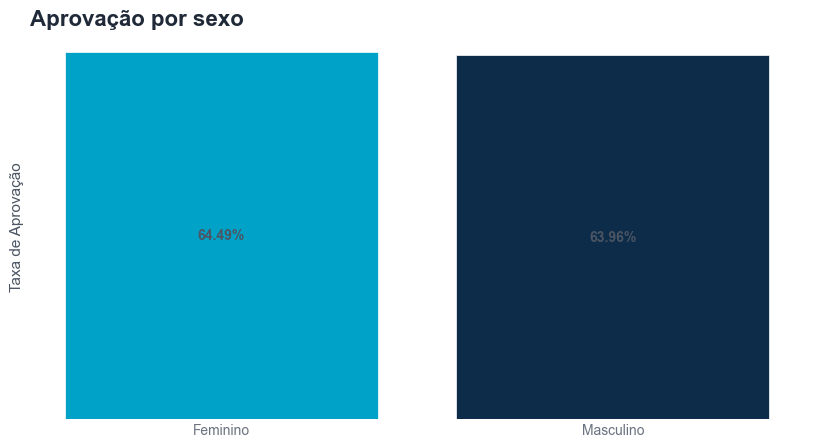

In [227]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(aprovados_sexo.index, aprovados_sexo.values.flatten(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Taxa de Aprovação')
plt.title('Aprovação por sexo', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.xticks(aprovados_sexo.index, ['Feminino', 'Masculino'])
plt.box(False)
plt.grid(False)

plt.savefig('aprov_by_sex.png', transparent=True, bbox_inches='tight', dpi=300)

plt.show()

A seleção é indistinta quanto ao sexo do candidato.

# **Análise por orientação sexual**

In [228]:
aprovados_orientacao = df.groupby(['OrientacaoSexual'])['Selecionado'].mean().round(4).to_frame()*100
aprovados_orientacao

,Selecionado
OrientacaoSexual,
Bissexual,64.52
Heterossexual,63.59
Homossexual,67.15
Outro,75.00
Pansexual,65.26
Prefiro não responder,63.89


In [229]:
df['OrientacaoSexual'].value_counts().to_frame()

,count
OrientacaoSexual,
Heterossexual,1851
Bissexual,620
Homossexual,274
Prefiro não responder,144
Pansexual,95
Outro,16


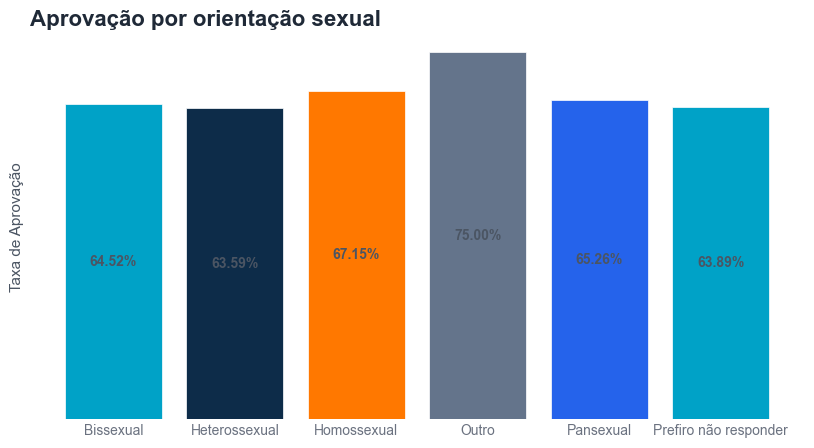

In [230]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(aprovados_orientacao.index, aprovados_orientacao.values.flatten(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Taxa de Aprovação')
plt.title('Aprovação por orientação sexual', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.box(False)
plt.grid(False)

plt.savefig('aprov_by_sex_orientacao.png', dpi=300)

plt.show()

Apesar da categoria **Outro** apresentar uma taxa de aprovação consideravelmente maior que a média dos demais, esse grupo representa apenas 0.5% do total do banco de dados. Sendo assim, não é possível dizer que a seleção do processo seletivo não é discriminatória quanto a orientação sexual do candidato. 

# **Análise por idade**

In [231]:
df['Idade'].value_counts().to_frame().sort_index()

,count
Idade,
17,18
18,317
19,370
20,443
21,393
22,364
23,307
24,196
25,155


In [232]:
aprovados_idade = df.groupby('Idade')['Selecionado'].mean().round(4).to_frame()*100
aprovados_idade


,Selecionado
Idade,
17,77.78
18,63.09
19,58.38
20,66.37
21,62.34
22,65.66
23,67.43
24,65.31
25,69.03


In [233]:
new_idade_bins = [17, 21, 26, 31, 41, int(df['Idade'].max())]
new_idade_labels = ['17-20', '21-25', '26-30', '31-40', '41+']
df['FaixaEtaria'] = pd.cut(df['Idade'], bins=new_idade_bins, labels=new_idade_labels, right=False)
df.head()

,Selecionado,Sexo,OrientacaoSexual,Idade,Raça-cor,Deficiência,FaixaEtaria
0,1,F,Bissexual,25,Amarela,Não possuo,21-25
1,1,M,Heterossexual,24,Não informada,Não possuo,21-25
2,0,F,Prefiro não responder,22,Branca,Não possuo,21-25
3,0,M,Homossexual,20,Preta,Não possuo,17-20
4,1,F,Heterossexual,21,Branca,Não possuo,21-25


In [234]:
df['FaixaEtaria'].value_counts().sort_index().to_frame()


,count
FaixaEtaria,
17-20,1148
21-25,1415
26-30,312
31-40,98
41+,26


In [235]:
df_faixas_idade = df['FaixaEtaria'].value_counts(normalize=True).sort_index().to_frame().round(4)*100
df_faixas_idade

,proportion
FaixaEtaria,
17-20,38.28
21-25,47.18
26-30,10.40
31-40,3.27
41+,0.87


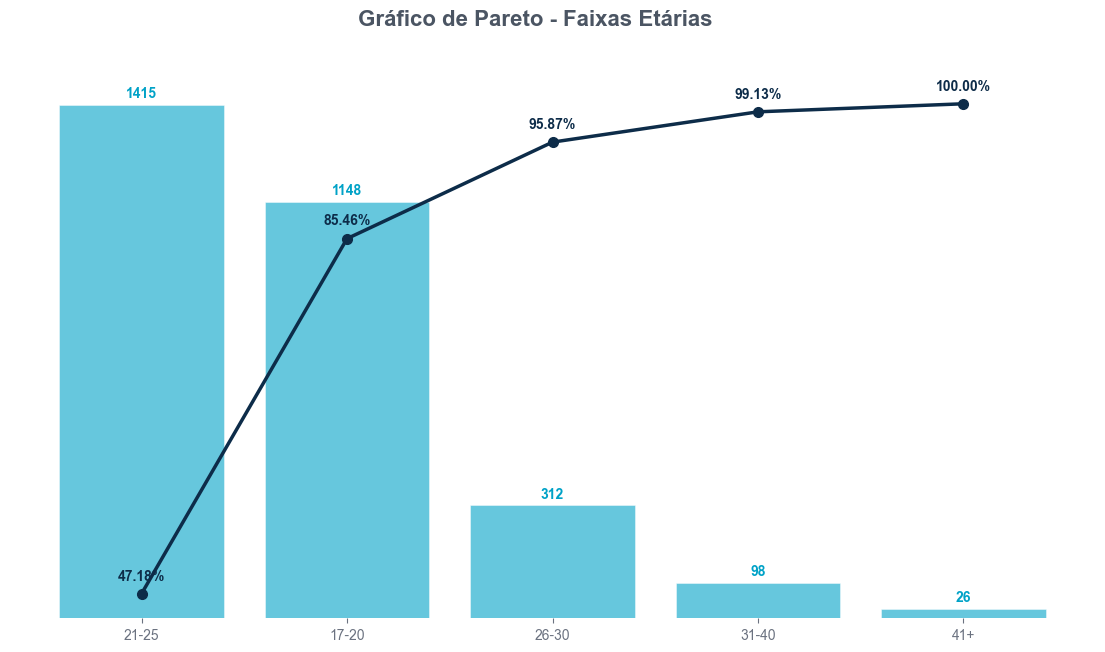

In [236]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Preparar os dados ordenados 
contagens = df['FaixaEtaria'].value_counts() # Já vem ordenado do maior para o menor
porcentagens_acumuladas = (contagens.cumsum() / contagens.sum()) * 100

fig, axs = plt.subplots(figsize=(14, 7))
ax2 = axs.twinx()

# 2. Gráfico de Barras
barras = axs.bar(contagens.index, contagens.values, color='C0', alpha=0.6)
axs.set_yticks([])
axs.bar_label(barras, padding=3, fontweight='bold', color='C0')
axs.grid(False)

# 3. Gráfico de Linha (Frequência Acumulada em %)
ax2.plot(contagens.index, porcentagens_acumuladas, color='C1', marker='o')
ax2.set_yticks([])

# 4. Adicionar os rótulos das porcentagens 
for x, y in zip(contagens.index, porcentagens_acumuladas):
    ax2.annotate(f'{y:.2f}%', (x, y), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 color='C1', 
                 fontweight='bold')


for ax in [axs, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('Gráfico de Pareto - Faixas Etárias', fontsize=16, fontweight='bold')
plt.savefig('pareto_faixas_etarias.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

In [237]:
aprovados_idade1 = df.groupby('FaixaEtaria')['Selecionado'].mean().round(4).to_frame()*100
aprovados_idade1

,Selecionado
FaixaEtaria,
17-20,63.07
21-25,65.44
26-30,65.06
31-40,62.24
41+,50.00


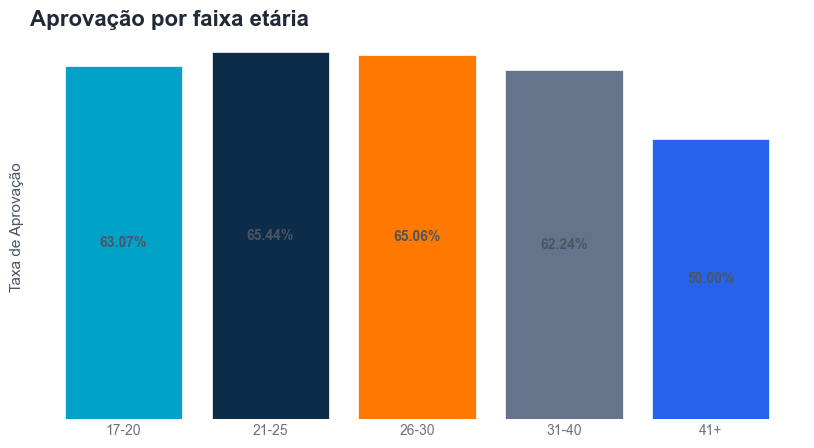

In [238]:
fig, ax = plt.subplots(figsize=(10, 5))    

ax.bar(aprovados_idade1.index, aprovados_idade1.values.flatten(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Taxa de Aprovação')
plt.title('Aprovação por faixa etária', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.xticks(aprovados_idade1.index, aprovados_idade1.index)
plt.box(False)
plt.grid(False)

plt.savefig('aprov_by_age.png', transparent=True, bbox_inches='tight', dpi=300)

plt.show()

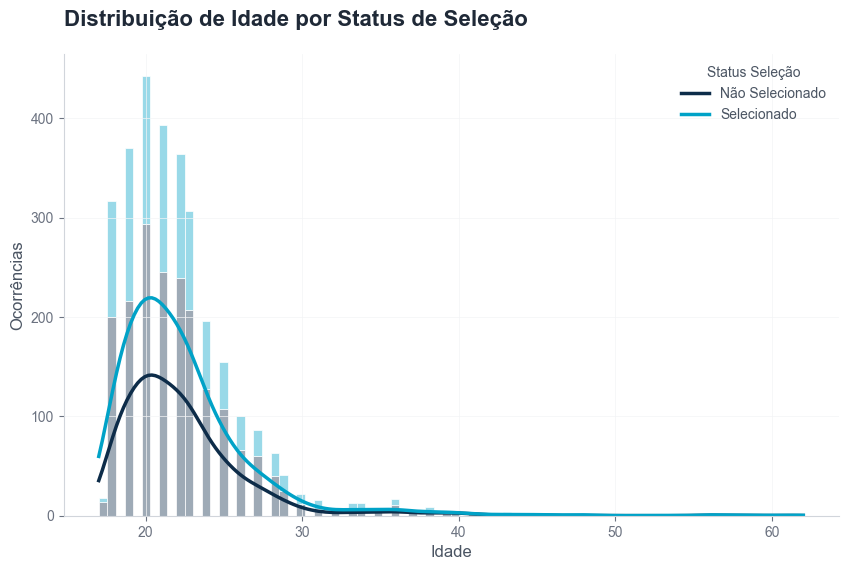

In [239]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Idade", hue="Selecionado", 
             kde=True, fill=True, alpha=0.4, multiple="stack")

plt.title(" ", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Idade", fontsize=12)
plt.ylabel("Ocorrências", fontsize=12)
plt.title("Distribuição de Idade por Status de Seleção", fontsize=16, fontweight='bold', pad=20)


plt.legend(title='Status Seleção', labels=['Não Selecionado', 'Selecionado'], frameon=False)


sns.despine()


plt.savefig('idade_selecionado.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

Naturalmente, a maioria dos dos candidatos, 85% deles, tem até 25 anos. Pessoas, com 41 anos ou mais, representam menos de 1% do total da base de dados. Ainda assim, possuem uma taxa de aprovação de 50%, um pouco abaixo da média dos demais grupos de idade (64%), o que indica que o processo seletivo não é discriminatório com candidatos mais velhos.

# **Análise por raça-cor**

In [240]:
df['Raça-cor'].value_counts(normalize=True).round(4).sort_values(ascending=False).to_frame()*100

,proportion
Raça-cor,
Branca,53.20
Parda,29.33
Preta,11.10
Não informada,4.17
Amarela,2.10
Indígena,0.10


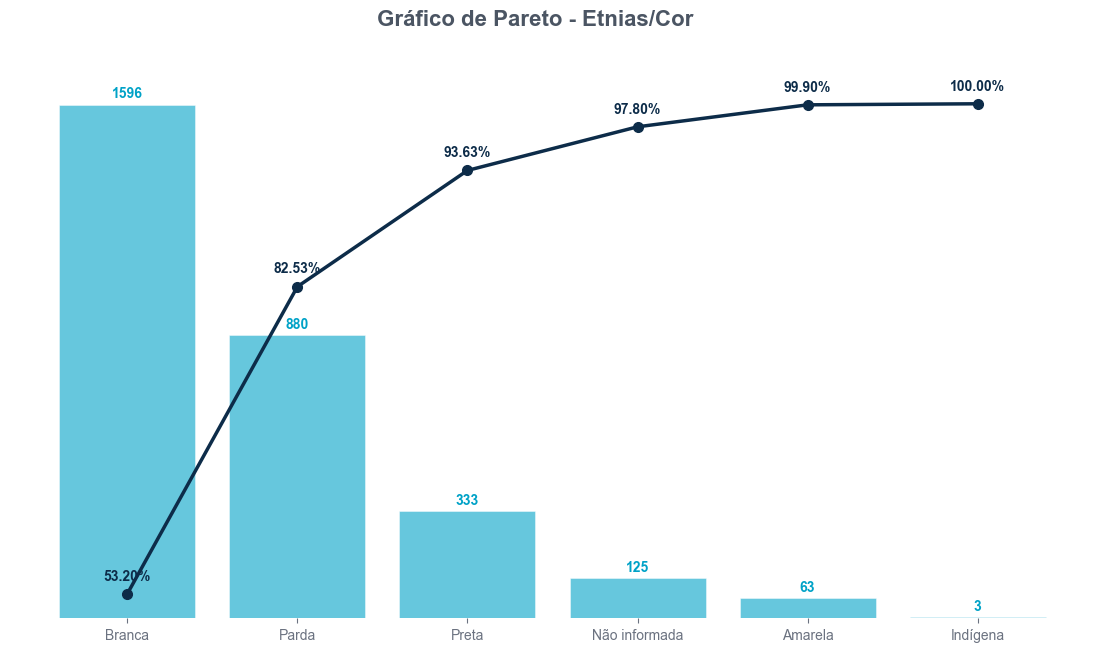

In [241]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Preparar os dados ordenados 
contagens = df['Raça-cor'].value_counts() # Já vem ordenado do maior para o menor
porcentagens_acumuladas = (contagens.cumsum() / contagens.sum()) * 100

fig, axs = plt.subplots(figsize=(14, 7))
ax2 = axs.twinx()

# 2. Gráfico de Barras
barras = axs.bar(contagens.index, contagens.values, color='C0', alpha=0.6)
axs.set_yticks([])
axs.bar_label(barras, padding=3, fontweight='bold', color='C0')
axs.grid(False)

# 3. Gráfico de Linha (Frequência Acumulada em %)
ax2.plot(contagens.index, porcentagens_acumuladas, color='C1', marker='o')
ax2.set_yticks([])

# 4. Adicionar os rótulos das porcentagens 
for x, y in zip(contagens.index, porcentagens_acumuladas):
    ax2.annotate(f'{y:.2f}%', (x, y), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 color='C1', 
                 fontweight='bold')


for ax in [axs, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('Gráfico de Pareto - Etnias/Cor', fontsize=16, fontweight='bold')
plt.savefig('pareto_racas.png', transparent=True, bbox_inches='tight', dpi=300)
plt.show()

Existem apenas 3 indígenas declarados no dataset, portanto, não é fazer uma análise específica desse grupo comparando-os com os demais.

In [242]:
aprovados_raca = df.groupby('Raça-cor')['Selecionado'].mean().round(4).sort_index().to_frame()*100
aprovados_raca

,Selecionado
Raça-cor,
Amarela,52.38
Branca,56.95
Indígena,33.33
Não informada,68.00
Parda,72.27
Preta,78.98


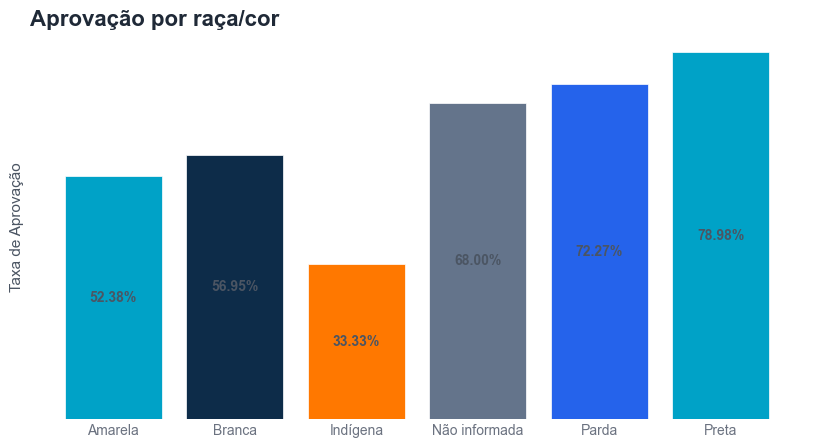

In [243]:
fig, ax = plt.subplots(figsize=(10, 5))    

ax.bar(aprovados_raca.index, aprovados_raca.values.flatten(), color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.ylabel('Taxa de Aprovação')
plt.title('Aprovação por raça/cor', fontweight='bold')
plt.bar_label(ax.containers[0], fmt='%.2f%%', label_type='center', fontweight='bold')
plt.tick_params(axis='x', length=0)
plt.yticks([])
plt.xticks(aprovados_raca.index, aprovados_raca.index)
plt.box(False)
plt.grid(False)

plt.savefig('aprov_by_race.png', transparent=True, bbox_inches='tight', dpi=300)

plt.show()

Brancos representam mais da metade dos candidatos, já pretos e pardos representam somados, cerca de 40%. Entretanto, esses grupos tem taxa de aprovação cosideravelmente maior, próximo de 80%, já os brancos e amarelos estão na casa dos 50% de aprovação. Isso indica que o processo seletivo tende por ações afirmativas quanto a etnia/cor de seus candidatos, já que esses grupos tendem a ser proporcionalmente mais vulneráveis economicante e com menos oportunidades de educação de qualidade.

Vamos fazer um teste de qui-quadrado para avaliara dependência estatística entre variáveis Raça-cor e Selecionado.

In [244]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [245]:
import pandas as pd
from scipy.stats import chi2_contingency

# tabela de contingência
tabela_raca = pd.crosstab(df['Raça-cor'], df['Selecionado'])

chi2, p, dof, expected = chi2_contingency(tabela_raca)

print("Raça-cor")
print("p-valor:", p)
print("graus de liberdade:", dof)

Raça-cor
p-valor: 8.81524773466973e-20
graus de liberdade: 5


O resultado obtido (p < 0.001) indica evidência estatisticamente significativa de dependência entre as variáveis, sugerindo que a distribuição de candidatos selecionados varia entre os diferentes grupos raciais.

Essa associação não implica causalidade, podendo refletir tanto características da amostra quanto fatores não observados no conjunto de dados. Entretanto reforça matematicamente a hipótese de que o processo seletivo para a bolsa avalia a vulnerabilidade socioeconômica do candidato.

# **A nálise por deficiência**

In [246]:
df['Deficiência'].value_counts().to_frame()

,count
Deficiência,
Não possuo,2886
Outro,42
Deficiência Visual,25
TEA – Transtorno Espectro do Autismo,21
Deficiência Mental/Intelectual,11
Deficiência Física,11
Deficiência Auditiva,4


In [247]:
aprovados_def = df.groupby('Deficiência')['Selecionado'].mean().round(4).sort_index().to_frame()*100
aprovados_def

,Selecionado
Deficiência,
Deficiência Auditiva,75.00
Deficiência Física,72.73
Deficiência Mental/Intelectual,63.64
Deficiência Visual,56.00
Não possuo,64.21
Outro,73.81
TEA – Transtorno Espectro do Autismo,52.38


In [248]:
aprovados_def_etnia = df.groupby(['Deficiência','Raça-cor'])['Selecionado'].mean().unstack().round(4).sort_index()*100
aprovados_def_etnia

Raça-cor,Amarela,Branca,Indígena,Não informada,Parda,Preta
Deficiência,,,,,,
Deficiência Auditiva,NaN,100.00,NaN,0.00,NaN,100.00
Deficiência Física,100.00,50.00,NaN,NaN,80.00,NaN
Deficiência Mental/Intelectual,100.00,83.33,NaN,0.00,0.00,50.00
Deficiência Visual,NaN,43.75,NaN,100.00,71.43,NaN
Não possuo,50.85,56.80,33.33,68.64,72.37,79.19
Outro,0.00,70.59,NaN,66.67,78.57,85.71
TEA – Transtorno Espectro do Autismo,NaN,57.14,NaN,NaN,50.00,0.00


Uma análise superficial dessas tabelas pode indicar que o processo seletivo da bolsa também tende a selecionar pessoas portadoras de alguma deficiência, mas como hámuitas categoraias, essa análise fica dificultada. Sendo assim, as pessoas com alguma deficiência serão colocadas em um único grupo para que possamos fazer uma análise mais simples e com mais facilidade de comprovação estatística.

In [249]:
def_labels = {
    'Não possuo': 'Não',
    'Deficiência Auditiva': 'Sim',
    'Deficiência Física': 'Sim',
    'Deficiência Visual': 'Sim',
    'TEA – Transtorno Espectro do Autismol': 'Sim',
    'Outro': 'Sim'
}

In [250]:
df['Deficiência Simplificada'] = df['Deficiência'].map(def_labels)
df.head()

,Selecionado,Sexo,OrientacaoSexual,Idade,Raça-cor,Deficiência,FaixaEtaria,Deficiência Simplificada
0,1,F,Bissexual,25,Amarela,Não possuo,21-25,Não
1,1,M,Heterossexual,24,Não informada,Não possuo,21-25,Não
2,0,F,Prefiro não responder,22,Branca,Não possuo,21-25,Não
3,0,M,Homossexual,20,Preta,Não possuo,17-20,Não
4,1,F,Heterossexual,21,Branca,Não possuo,21-25,Não


In [251]:
tabela_def = pd.crosstab(df['Deficiência Simplificada'], df['Selecionado'])

chi2, p, dof, expected = chi2_contingency(tabela_def)

print("Deficiência")
print("p-valor:", p)

Deficiência
p-valor: 0.519083142709613


Apesar de pequenas variações observadas na análise descritiva, o teste estatístico não indica relação significativa entre deficiência e seleção. Isso sugere que essa variável, isoladamente, não apresenta poder explicativo relevante no processo analisado.

Além disso, a baixa representatividade de alguns grupos pode limitar a capacidade de detectar possíveis diferenças.

Enquanto a variável raça/cor apresenta associação estatisticamente significativa com a seleção, o mesmo não ocorre para deficiência, indicando que nem todas as características demográficas possuem o mesmo nível de relação com o resultado do processo.

# **Regressão logística**

Para avaliar o impacto conjunto das variáveis, será estimado um modelo de regressão logística. 

In [252]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [253]:
X = df[['Sexo', 'Raça-cor', 'OrientacaoSexual', 'FaixaEtaria', 'Deficiência Simplificada']]

X = pd.get_dummies(X, drop_first=True)

y = df['Selecionado']

In [254]:
X = X.astype(float)
y = y.astype(float)

In [255]:
import statsmodels.api as sm

X = sm.add_constant(X)

In [256]:
modelo = sm.Logit(y, X).fit()

print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.633695
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            Selecionado   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2983
Method:                           MLE   Df Model:                           16
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.02817
Time:                        16:35:39   Log-Likelihood:                -1901.1
converged:                       True   LL-Null:                       -1956.2
Covariance Type:            nonrobust   LLR p-value:                 4.089e-16
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                      0.0626   

Os resultados indicam que apenas a variável raça/cor apresenta associação estatisticamente significativa com a seleção, mesmo após o controle das demais variáveis.

Em particular, candidatos que se autodeclaram pretos ou pardos apresentam maior probabilidade de seleção em relação ao grupo de referência.

Por outro lado, variáveis como sexo, idade, orientação sexual e deficiência não apresentaram significância estatística, sugerindo baixo poder explicativo no contexto analisado.

Isso sustenta a hipótese de que a bolsa tem objetivo de apoior pessoas mais vulneráveis socioeconomicamente. Entretanto, para confirmar isso, seria necessário informações como renda familiar percapita, se o candidato estudou ou não em escula pública e similares, informações que não estão disponíveis no dataset.